## 1. Setup Notebook

**Model configuration**
- Select `.yaml` file defining model, solver, and outputs  
- All configs are located in `Automation/configs/`  
- Add new models by extending the `MODEL_TO_CONFIG` dictionary  

**Run modes**
- `"run_missing"`: run only simulations without existing `run_summary.json`  
- `"overwrite"`: rerun all simulations (ignore existing results)  
- `"load_only"`: load existing summaries only (no simulations executed)  

**Parallelization (`workers`)**
- Number of simulations executed in parallel (separate processes)  
- Not a direct core assignment, but effectively controls CPU usage  
- Guideline: use ~60–80% of available CPU cores  
  - Example: 12-core machine → 8–10 workers is typically optimal
 
**Repository setup**
- Detects and sets the repository root path  
- Adds repo root to `sys.path` for module imports  
- Prints: `.../Automation_main`

In [10]:
# -------------------------
# INPUT (edit only here)
# -------------------------

# Model selection: (must exist in MODEL_TO_CONFIG below)
MODEL = "Dupi"

# Run modes:
MODE = "run_missing"

# Parallelization: Number of parallel workers
workers = 8  


# -------------------------
# IMPORTS
# -------------------------

import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, PercentFormatter, LogFormatterSciNotation
from matplotlib.gridspec import GridSpec
from scipy.interpolate import PchipInterpolator
import importlib, hashlib, json as _json
from scripts.runner import run_sweep, load_config

# -------------------------
# Resolve repository root
# -------------------------

# If running from /notebooks, go one level up
# Otherwise assume current working directory is repo root
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Adds repo root to Python path so imports like `scripts.runner` work
sys.path.insert(0, str(repo_root))

print("repo_root:", repo_root)


# -------------------------
# Model → config mapping
# -------------------------

# Maps model names to their YAML configuration files
MODEL_TO_CONFIG = {
    "Kapitanov": repo_root / "configs" / "Kapitanov_sweep.yaml",
    "Walz": repo_root / "configs" / "Walz_sweep.yaml",
    "Tiraboschi": repo_root / "configs" / "Tiraboschi_sweep.yaml",
    "Lebri": repo_root / "configs" / "Lebri_sweep.yaml",
    "Dupi": repo_root / "configs" / "Dupi_sweep.yaml",
}

# Resolve selected config
config_path = MODEL_TO_CONFIG[MODEL]
print("Using config:", config_path)

repo_root: C:\Users\LevinSchöpfer\Automation_main
Using config: C:\Users\LevinSchöpfer\Automation_main\configs\Dupi_sweep.yaml


## 2. Define parameter grid + run sweep

**Input definition**

**Dose input (two mutually exclusive modes)**

- **Manual mode (`DOSE_MODE = "manual"`)**
  - Provide an explicit list of dose values  
  - Example:
    ```python
    dose_values_manual = [0.1, 1, 10, 100]
    ```

- **Geometric mode (`DOSE_MODE = "geometric"`)**
  - Automatically generate log-spaced doses  
  - Format: `[lower, upper, n]`
    - `lower`: minimum dose (> 0)
    - `upper`: maximum dose
    - `n`: number of points  
  - Example:
    ```python
    dose_specification = [0.1, 5000, 30]
    ```

→ The notebook enforces that only one mode is active.

**Execution**

- Generates full grid:  
  `len(dose_values) × len(interval_values)`

- Calls `Runner.py` to run or load simulations (depending on `MODE`)

- Automatically:
  - Stores results under a parameter-specific folder (`params_<hash>`)
  - Loads all available summaries
  - Filters results strictly to the requested grid

**Validation / completeness check**

- Compares:
  - **Expected runs** (grid size)
  - **Actual runs** (found summaries)

- If incomplete:
  - Prints missing `(dose, interval)` combinations

→ Ensures sweep integrity before plotting or analysis

In [3]:
# -------------------------
# INPUT
# -------------------------


# "geometric": generate log-spaced doses [lower, upper, n]
dose_values_geometric = [1, 500, 20]


# "manual": provide explicit list
dose_values_manual = [1, 10, 20]


# Choose dose input:
DOSE_MODE = "geometric"


# Dosing intervals (weeks): provide explicit list with integers only
interval_values = [2, 4, 8, 12]


# Parameter overrides
param_overrides = { }


# -------------------------
# GEOMETRIC SERIES FUNCTION
# -------------------------

def geometric_series(lower, upper, n, decimals=2): 
    if lower <= 0 or upper <= 0: 
        raise ValueError("Bounds must be > 0 for a geometric series.") 
    if n < 2: 
        raise ValueError("n must be at least 2.") 
    r = (upper / lower) ** (1 / (n - 1)) 
    vals = [round(lower * r**i, decimals) for i in range(n)] 
    vals = sorted(set(vals)) 
    return vals

# -------------------------
# RESOLVE DOSE VALUES
# -------------------------

if DOSE_MODE == "manual":
    if not dose_values_manual:
        raise ValueError("DOSE_MODE='manual' but dose_values_manual is empty.")
    dose_values = sorted(set(dose_values_manual))

elif DOSE_MODE == "geometric":
    dose_values = geometric_series(*dose_values_geometric, decimals=2)

else:
    raise ValueError(f"Unknown DOSE_MODE: {DOSE_MODE}")


print("Dose values:", dose_values)
print("Intervals:", interval_values)


# -------------------------
# CONFIG + PARAMETER HASHING
# -------------------------

# Load model config and module
cfg = load_config(config_path)
model_module = importlib.import_module(cfg["model"]["module"])


def canonicalize_params(obj):
    """
    Convert parameters into a deterministic, JSON-stable format
    (ensures reproducible hashing).
    """
    if isinstance(obj, dict):
        return {k: canonicalize_params(obj[k]) for k in sorted(obj)}
    if isinstance(obj, (list, tuple)):
        return [canonicalize_params(x) for x in obj]
    if hasattr(obj, "item") and callable(obj.item):
        try:
            return obj.item()
        except Exception:
            pass
    if isinstance(obj, float):
        return float(f"{obj:.12g}")
    return obj


def params_fingerprint(params: dict) -> str:
    """
    Generate unique hash for a parameter set.
    Used to separate results for different model configurations.
    """
    payload = _json.dumps(canonicalize_params(params), sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()[:12]


# Build effective parameter set:
# DEFAULTS + YAML params + overrides
effective_params = dict(getattr(model_module, "DEFAULTS", {}))
effective_params.update(cfg.get("params", {}))
if param_overrides:
    effective_params.update(param_overrides)

# Compute parameter ID → determines output folder
param_id = params_fingerprint(effective_params)

base_root = repo_root / cfg["output"]["root_dir"]
out_root = base_root / f"params_{param_id}"

print("Loading/running in:", out_root)


# -------------------------
# LOAD HELPERS
# -------------------------

def load_all_summaries(out_root: Path) -> pd.DataFrame:
    """
    Load all run_summary.json files from parameter folder.
    """
    rows = []
    for p in sorted(out_root.glob("*/run_summary.json")):
        with open(p, "r", encoding="utf-8") as f:
            d = json.load(f)
        d["_run_dir"] = str(p.parent)
        rows.append(d)
    return pd.DataFrame(rows)


def filter_to_grid_exact(df: pd.DataFrame, dose_values, interval_values) -> pd.DataFrame:
    """
    Keep only rows matching the requested (dose, interval) grid.
    Prevents mixing results from previous runs.
    """
    if df.empty:
        return df

    df = df.copy()
    df["dose_mgkg"] = df["dose_mgkg"].astype(float)
    df["interval_weeks"] = df["interval_weeks"].astype(int)

    requested = set((float(d), int(i)) for d in dose_values for i in interval_values)

    mask = [
        (float(r.dose_mgkg), int(r.interval_weeks)) in requested
        for r in df.itertuples(index=False)
    ]
    return df.loc[mask]


# -------------------------
# RUN OR LOAD
# -------------------------

if MODE == "load_only":
    # Only read existing results
    df_all = load_all_summaries(out_root)

else:
    # Run sweep (parallelized via `workers`)
    df = run_sweep(
        config_path=config_path,
        dose_values=dose_values,
        interval_values=interval_values,
        workers=workers,
        overwrite=(MODE == "overwrite"),
        param_overrides=param_overrides,
    )

    # Reload all summaries (ensures consistency)
    df_all = load_all_summaries(out_root)


# Filter strictly to requested grid
df = filter_to_grid_exact(df_all, dose_values, interval_values)

# Sort for clean downstream plotting
if not df.empty:
    df["interval_weeks"] = df["interval_weeks"].astype(int)
    df = df.sort_values(["interval_weeks", "dose_mgkg"]).reset_index(drop=True)

df.head


# -------------------------
# COMPLETENESS CHECK
# -------------------------

expected = len(dose_values) * len(interval_values)
actual = len(df)

print("Expected runs:", expected)
print("Found runs:", actual)

# Identify missing simulations
if actual != expected:
    found = set(
        (float(r.dose_mgkg), int(r.interval_weeks))
        for r in df.itertuples(index=False)
    )

    missing = [
        (float(d), int(i))
        for d in dose_values
        for i in interval_values
        if (float(d), int(i)) not in found
    ]

    print("Missing combos:", missing[:30], "..." if len(missing) > 30 else "")

Dose values: [1.0, 1.3869189, 1.9235439, 2.6677993, 3.7000212, 5.1316292, 7.1171532, 9.870914, 13.6901568, 18.9871366, 26.3336178, 36.5225911, 50.6538703, 70.2528079, 97.434944, 135.1343612, 187.4203937, 259.9368781, 360.5113577, 500.0]
Intervals: [2, 4, 8, 12]
Loading/running in: C:\Users\LevinSchöpfer\Automation_main\results\Dupi_sweep\params_b104ecf6950e
Expected runs: 80
Found runs: 80


## 3. Plot sweep output

This cell generates exposure-response plot from the current sweep results in `df`.

### Output
- **Left panel:** PD response vs. `C_avg`
- **Right panel:** PD response vs. `C_trough`

### User settings

- **PD masking**
  - `PD_MIN` and `PD_MAX` define which PD values are displayed

- **Axis settings**
  - `XAUTO = True` automatically chooses an appropriate x-axis range from the plotted data
  - `YAUTO = True` automatically chooses an appropriate y-axis range from the plotted data
  - If `XAUTO` or `YAUTO` is `False`, the manual settings are used instead

- **Summary text**
  - `show_summary_text = True` adds a text block below the plot with:
    - model parameters
    - PD masking settings
    - shown dose ranges after masking


### Notes
- The PD trough column is detected automatically from `df`
- The plot uses only the currently loaded sweep results
- The exported file name includes:
  - model name
  - dose range
  - interval range

C:\Users\LevinSchöpfer\AppData\Local\Temp\ipykernel_17512\1627719941.py:523: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


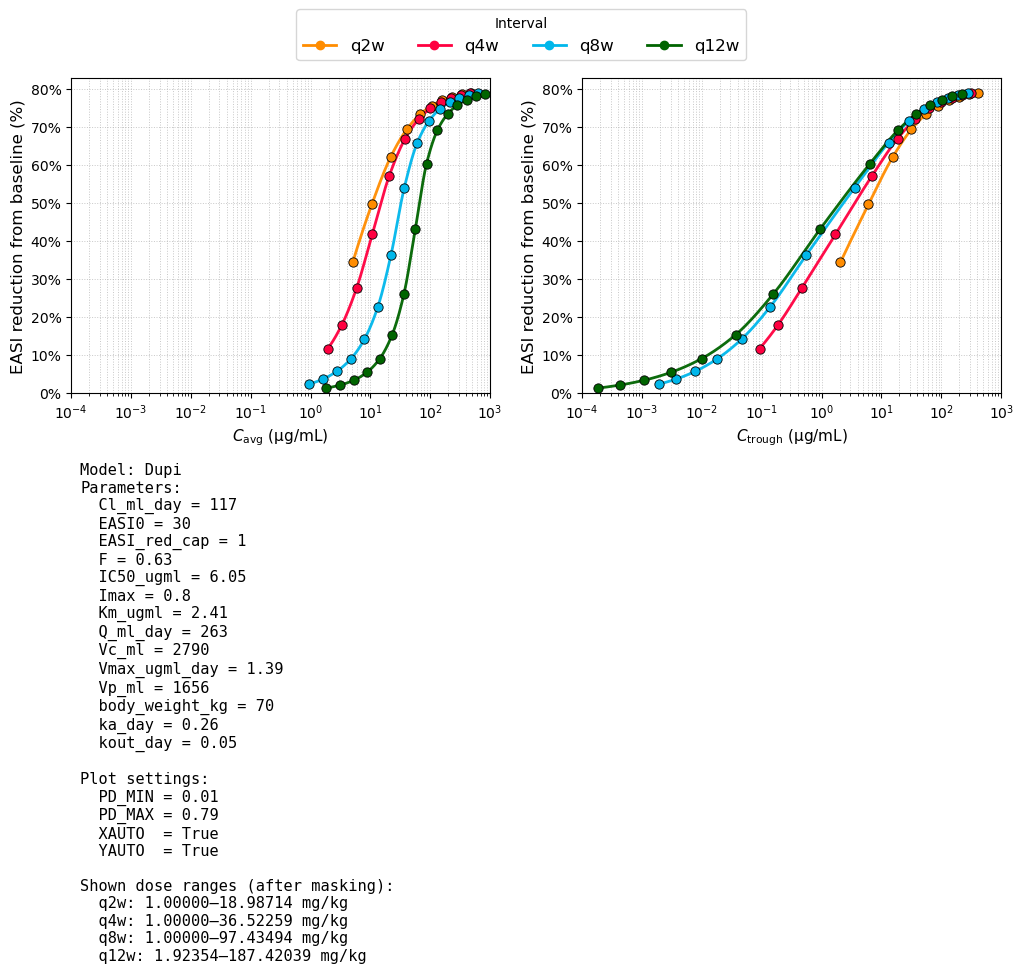

In [11]:
# -------------------------
# INPUT
# -------------------------


# PD masking
PD_MIN = 0.01
PD_MAX = 0.79


# X-axis settings
XAUTO = True
XMIN = 0.01
XMAX = 1000
XTICKS = [0.01, 0.1, 1, 10, 100, 1000]


# Y-axis settings
YAUTO = True
YMIN = 0
YMAX = 100


# Summary text
show_summary_text = True


# -------------------------
# BASIC CHECKS
# -------------------------

if df.empty:
    raise RuntimeError("DataFrame `df` is empty. Run the sweep or load summaries first.")

# -------------------------
# DETECT PD TROUGH COLUMN
# -------------------------
# Automatically find the PD trough column in df.

pd_candidates = [c for c in df.columns if c.endswith("_trough") and c not in ["C_trough_ugml"]]

if "RO3_trough" in pd_candidates:
    pd_col = "RO3_trough"
elif "TARC_red_trough" in pd_candidates:
    pd_col = "TARC_red_trough"
elif "EASI_red_trough" in pd_candidates:
    pd_col = "EASI_red_trough"
elif len(pd_candidates) == 1:
    pd_col = pd_candidates[0]
else:
    raise RuntimeError(f"Could not determine PD trough column uniquely. Candidates: {pd_candidates}")


# -------------------------
# AUTOMATIC Y-AXIS LABEL
# -------------------------
# Convert model-specific PD key into a readable axis label.

pd_key = cfg.get("outputs", {}).get("pd_key")

if pd_key == "RO3":
    y_title = "Occupied IL-4R at SoA"
elif pd_key == "TARC_red":
    y_title = "TARC reduction from baseline"
elif pd_key == "EASI_red":
    y_title = "EASI reduction from baseline"
elif pd_key == "EASI_norm":
    y_title = "Placebo-corrected EASI reduction from baseline"
else:
    y_title = pd_key if pd_key is not None else pd_col.replace("_trough", "")


# -------------------------
# SETUP COLORS AND INTERVALS
# -------------------------

intervals = sorted(df["interval_weeks"].astype(int).unique())
base_colors = ["#FF8C00", "#FF0040", "#00B7EB", "#006400", "#7A1FA2", "#D3B683"]
colors = [base_colors[i % len(base_colors)] for i in range(len(intervals))]


# -------------------------
# HELPER FUNCTIONS
# -------------------------

def smooth_curve_logx(x, y, n_points=250):
    """
    Smooth y over log10(x) using PCHIP interpolation.
    Returns smoothed x and y arrays.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = (x > 0) & np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return None, None

    x = x[mask]
    y = y[mask]

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    # Average duplicate x values before interpolation
    xu, inv = np.unique(x, return_inverse=True)
    if len(xu) != len(x):
        y_acc = np.zeros_like(xu, dtype=float)
        counts = np.zeros_like(xu, dtype=int)
        for i, idx in enumerate(inv):
            y_acc[idx] += y[i]
            counts[idx] += 1
        y = y_acc / counts
        x = xu

    if len(x) < 2:
        return None, None

    lx = np.log10(x)
    lx_smooth = np.linspace(lx.min(), lx.max(), n_points)
    f = PchipInterpolator(lx, y)
    y_smooth = f(lx_smooth)
    x_smooth = 10 ** lx_smooth

    return x_smooth, y_smooth


def format_param_summary(cfg, model_module, effective_params):
    """
    Return text block with model parameters and optional microconstants.
    """
    lines = []
    lines.append(f"Model: {cfg['model']['name']}")
    lines.append("Parameters:")

    for k, v in sorted(effective_params.items()):
        if isinstance(v, float):
            lines.append(f"  {k} = {v:g}")
        else:
            lines.append(f"  {k} = {v}")

    if hasattr(model_module, "microconstants"):
        try:
            mcs = model_module.microconstants(effective_params)
            if mcs:
                lines.append("Microconstants:")
                for k, v in sorted(mcs.items()):
                    if isinstance(v, float):
                        lines.append(f"  {k} = {v:g}")
                    else:
                        lines.append(f"  {k} = {v}")
        except Exception as e:
            lines.append(f"Microconstants: error ({e})")

    return "\n".join(lines)


def format_plot_settings(PD_MIN, PD_MAX, XAUTO, YAUTO, XMIN, XMAX, YMIN, YMAX):
    """
    Return text block summarizing masking and axis settings.
    """
    lines = []
    lines.append("Plot settings:")
    lines.append(f"  PD_MIN = {PD_MIN:g}")
    lines.append(f"  PD_MAX = {PD_MAX:g}")
    lines.append(f"  XAUTO  = {XAUTO}")
    lines.append(f"  YAUTO  = {YAUTO}")

    if not XAUTO:
        lines.append(f"  XMIN   = {XMIN:g}")
        lines.append(f"  XMAX   = {XMAX:g}")

    if not YAUTO:
        lines.append(f"  YMIN   = {YMIN:g}")
        lines.append(f"  YMAX   = {YMAX:g}")

    return "\n".join(lines)


def format_dose_ranges_shown(df, intervals, pd_col, mask_min=None, mask_max=None, decimals=5):
    """
    Return shown dose ranges after PD masking for each interval.
    """
    lines = ["Shown dose ranges (after masking):"]

    for iw in intervals:
        dfi = df[df["interval_weeks"].astype(int) == int(iw)].copy()

        if mask_min is not None:
            dfi = dfi[dfi[pd_col].astype(float) >= mask_min]
        if mask_max is not None:
            dfi = dfi[dfi[pd_col].astype(float) <= mask_max]

        if dfi.empty:
            lines.append(f"  q{iw}w: (none)")
            continue

        doses = dfi["dose_mgkg"].astype(float).values
        dmin = float(doses.min())
        dmax = float(doses.max())
        lines.append(f"  q{iw}w: {dmin:.{decimals}f}–{dmax:.{decimals}f} mg/kg")

    return "\n".join(lines)


def sanitize_for_filename(value):
    """
    Convert numeric value into a compact filename-safe string.
    Example: 0.01 -> 0p01
    """
    value = float(value)
    return f"{value:g}".replace(".", "p")


def choose_log_ticks(xmin, xmax):
    """
    Generate decade ticks for a log-scaled x-axis.
    """
    if xmin <= 0 or xmax <= 0:
        raise ValueError("Log-scale x-axis requires positive xmin and xmax.")

    lo = int(np.floor(np.log10(xmin)))
    hi = int(np.ceil(np.log10(xmax)))
    ticks = [10 ** k for k in range(lo, hi + 1)]

    # Also include xmin/xmax explicitly if they are not exact powers of 10
    if xmin not in ticks:
        ticks = [xmin] + ticks
    if xmax not in ticks:
        ticks = ticks + [xmax]

    # Deduplicate and sort
    ticks = sorted(set(float(t) for t in ticks))
    return ticks


def style_axis(ax, xmin, xmax, ymin, ymax, xticks, has_any=True):
    """
    Apply common formatting to one panel.
    """
    ax.set_xscale("log")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{t:g}" for t in xticks])
    ax.xaxis.set_major_formatter(LogFormatterSciNotation())

    ax.grid(which="both", linestyle=":", linewidth=0.7, alpha=0.7)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    if not has_any:
        ax.text(
            0.5, 0.5,
            "No points after masking",
            transform=ax.transAxes,
            ha="center", va="center",
            fontsize=12, alpha=0.7
        )


# -------------------------
# PREPARE PLOTTED DATA
# -------------------------
# Build per-interval plotting data once so:
# - the same masked data is used everywhere
# - auto axis limits can be determined cleanly

plot_data = []

for idx, iw in enumerate(intervals):
    dfi = df[df["interval_weeks"].astype(int) == int(iw)].copy()
    color = colors[idx]

    y = dfi[pd_col].astype(float).values
    pd_mask = (y >= PD_MIN) & (y <= PD_MAX) & np.isfinite(y)

    x_avg = dfi["C_avg_ugml"].astype(float).values
    x_tr = dfi["C_trough_ugml"].astype(float).values

    mask_cavg = pd_mask & (x_avg > 0) & np.isfinite(x_avg)
    mask_ctr = pd_mask & (x_tr > 0) & np.isfinite(x_tr)

    plot_data.append({
        "interval": iw,
        "color": color,
        "y_all": y,
        "x_avg": x_avg,
        "x_tr": x_tr,
        "mask_cavg": mask_cavg,
        "mask_ctr": mask_ctr,
    })


# -------------------------
# RESOLVE AXIS LIMITS
# -------------------------

# ----- X-axis -----
if XAUTO:
    xvals = []

    for item in plot_data:
        if item["mask_cavg"].sum() > 0:
            xvals.extend(item["x_avg"][item["mask_cavg"]].tolist())
        if item["mask_ctr"].sum() > 0:
            xvals.extend(item["x_tr"][item["mask_ctr"]].tolist())

    if len(xvals) == 0:
        raise RuntimeError("No positive finite x-values remain after masking. Cannot determine automatic x-axis.")

    xvals = np.asarray(xvals, dtype=float)
    xmin_auto = float(np.min(xvals))
    xmax_auto = float(np.max(xvals))

    # Expand to full log decades for cleaner display
    x_lo = 10 ** np.floor(np.log10(xmin_auto))
    x_hi = 10 ** np.ceil(np.log10(xmax_auto))

    active_xmin = float(x_lo)
    active_xmax = float(x_hi)
    active_xticks = choose_log_ticks(active_xmin, active_xmax)

else:
    active_xmin = float(XMIN)
    active_xmax = float(XMAX)
    active_xticks = list(XTICKS)


# ----- Y-axis -----
if YAUTO:
    yvals_percent = []

    for item in plot_data:
        if item["mask_cavg"].sum() > 0:
            yvals_percent.extend((100 * item["y_all"][item["mask_cavg"]]).tolist())
        if item["mask_ctr"].sum() > 0:
            yvals_percent.extend((100 * item["y_all"][item["mask_ctr"]]).tolist())

    if len(yvals_percent) == 0:
        raise RuntimeError("No PD values remain after masking. Cannot determine automatic y-axis.")

    yvals_percent = np.asarray(yvals_percent, dtype=float)
    ymin_auto = float(np.min(yvals_percent))
    ymax_auto = float(np.max(yvals_percent))

    # Add a small visual margin
    yr = ymax_auto - ymin_auto
    if yr <= 0:
        yr = max(1.0, 0.05 * ymax_auto if ymax_auto != 0 else 1.0)

    pad = 0.05 * yr
    active_ymin = max(0.0, ymin_auto - pad)
    active_ymax = min(100.0, ymax_auto + pad)

    if active_ymax <= active_ymin:
        active_ymin = max(0.0, ymin_auto - 1.0)
        active_ymax = min(100.0, ymax_auto + 1.0)

else:
    active_ymin = float(YMIN)
    active_ymax = float(YMAX)


# -------------------------
# CREATE FIGURE
# -------------------------

if show_summary_text:
    # Top row = two plots
    # Bottom row = one text panel spanning both columns
    fig = plt.figure(figsize=(12, 7))
    gs = GridSpec(2, 2, height_ratios=[3.2, 1.6], hspace=0.28, wspace=0.22)

    ax_cavg = fig.add_subplot(gs[0, 0])
    ax_ctr = fig.add_subplot(gs[0, 1])
    ax_txt = fig.add_subplot(gs[1, :])
    ax_txt.axis("off")

else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
    ax_cavg = axes[0]
    ax_ctr = axes[1]
    ax_txt = None


# -------------------------
# DRAW PLOTS
# -------------------------

legend_handles = []
any_cavg = False
any_ctr = False

for item in plot_data:
    iw = item["interval"]
    color = item["color"]
    y = item["y_all"]

    # ----- PD vs Cavg -----
    mask_cavg = item["mask_cavg"]
    x_avg = item["x_avg"]

    # Apply active x-range after auto/manual limits are resolved
    mask_cavg = mask_cavg & (x_avg >= active_xmin) & (x_avg <= active_xmax)

    if mask_cavg.sum() >= 1:
        any_cavg = True
        y_percent = 100 * y[mask_cavg]
        xs, ys = smooth_curve_logx(x_avg[mask_cavg], y_percent)
        if xs is not None:
            ax_cavg.plot(xs, ys, color=color, linewidth=2.0, alpha=0.95)
        ax_cavg.scatter(
            x_avg[mask_cavg], y_percent,
            color=color, edgecolor="k", linewidth=0.6, s=45, zorder=3
        )

    # ----- PD vs Ctrough -----
    mask_ctr = item["mask_ctr"]
    x_tr = item["x_tr"]
    mask_ctr = mask_ctr & (x_tr >= active_xmin) & (x_tr <= active_xmax)

    if mask_ctr.sum() >= 1:
        any_ctr = True
        y_percent = 100 * y[mask_ctr]
        xs, ys = smooth_curve_logx(x_tr[mask_ctr], y_percent)
        if xs is not None:
            ax_ctr.plot(xs, ys, color=color, linewidth=2.0, alpha=0.95)
        ax_ctr.scatter(
            x_tr[mask_ctr], y_percent,
            color=color, edgecolor="k", linewidth=0.6, s=45, zorder=3
        )

    legend_handles.append(
        plt.Line2D([0], [0], color=color, lw=2, marker="o", markersize=6, label=f"q{iw}w")
    )


# -------------------------
# STYLE AXES
# -------------------------

style_axis(ax_cavg, active_xmin, active_xmax, active_ymin, active_ymax, active_xticks, has_any=any_cavg)
style_axis(ax_ctr, active_xmin, active_xmax, active_ymin, active_ymax, active_xticks, has_any=any_ctr)

ax_cavg.set_xlabel(r"$C_{\mathrm{avg}}$ (µg/mL)", fontsize=11)
ax_ctr.set_xlabel(r"$C_{\mathrm{trough}}$ (µg/mL)", fontsize=11)

ax_cavg.set_ylabel(y_title + " (%)", fontsize=12)
ax_ctr.set_ylabel(y_title + " (%)", fontsize=12)


# -------------------------
# LEGEND
# -------------------------

legend_y = 0.99 if show_summary_text else 1.02
fig.legend(
    handles=legend_handles,
    title="Interval",
    fontsize=12,
    loc="upper center",
    ncol=max(1, len(intervals)),
    bbox_to_anchor=(0.5, legend_y),
)


# -------------------------
# SUMMARY TEXT PANEL
# -------------------------

if show_summary_text:
    summary_text = format_param_summary(
        cfg=cfg,
        model_module=model_module,
        effective_params=effective_params,
    )

    settings_text = format_plot_settings(
        PD_MIN=PD_MIN,
        PD_MAX=PD_MAX,
        XAUTO=XAUTO,
        YAUTO=YAUTO,
        XMIN=active_xmin if XAUTO else XMIN,
        XMAX=active_xmax if XAUTO else XMAX,
        YMIN=active_ymin if YAUTO else YMIN,
        YMAX=active_ymax if YAUTO else YMAX,
    )

    ranges_text = format_dose_ranges_shown(
        df=df,
        intervals=intervals,
        pd_col=pd_col,
        mask_min=PD_MIN,
        mask_max=PD_MAX,
        decimals=5,
    )

    full_text = (
        summary_text
        + "\n\n"
        + settings_text
        + "\n\n"
        + ranges_text
    )

    ax_txt.text(
        0.01, 0.98,
        full_text,
        ha="left",
        va="top",
        fontsize=11,
        family="monospace",
        transform=ax_txt.transAxes,
    )


# -------------------------
# LAYOUT
# -------------------------

if show_summary_text:
    plt.tight_layout(rect=[0, 0, 1, 0.94])
else:
    plt.tight_layout(rect=[0, 0, 1, 0.90])


# -------------------------
# SHOW FIGURE
# -------------------------

# Store the most recently generated figure for optional saving in the next cell
latest_fig = fig

# Show figure
plt.show()

## 4. Save most recent plot

This cell saves the most recently generated figure from cell 3.

### Behavior
- Saves `latest_fig` as a `.png`
- Save location:
  `.../results/sweep_plots/<MODEL>`
- Existing files with the same name are overwritten

### File name
The exported file name includes:
- model name
- dose range
- interval range

### Requirement
- Cell 3 must be run first so that `latest_fig` exists

In [12]:
# -------------------------
# SAVE SETTINGS
# -------------------------

# Resolution
save_dpi = 300

# -------------------------
# BASIC CHECK
# -------------------------

if "latest_fig" not in globals():
    raise RuntimeError("No plot found. Run cell 3 first to generate `latest_fig`.")

if latest_fig is None:
    raise RuntimeError("`latest_fig` is None. Run cell 3 first.")


# -------------------------
# HELPER
# -------------------------

def sanitize_for_filename(value):
    """
    Convert numeric value into a compact filename-safe string.
    Example: 0.01 -> 0p01
    """
    value = float(value)
    return f"{value:g}".replace(".", "p")


# -------------------------
# SAVE PATH
# -------------------------

plot_dir = repo_root / "results" / "sweep_plots" / MODEL
plot_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# BUILD FILE NAME
# -------------------------

dose_min = sanitize_for_filename(df["dose_mgkg"].astype(float).min())
dose_max = sanitize_for_filename(df["dose_mgkg"].astype(float).max())
interval_min = int(df["interval_weeks"].astype(int).min())
interval_max = int(df["interval_weeks"].astype(int).max())

png_name = (
    f"{MODEL}"
    f"_dose_{dose_min}_to_{dose_max}"
    f"_interval_{interval_min}_to_{interval_max}.png"
)

png_path = plot_dir / png_name


# -------------------------
# SAVE FIGURE
# -------------------------

# Overwrites existing file with same name
latest_fig.savefig(png_path, dpi=save_dpi, bbox_inches="tight")

print("Saved plot to:", png_path)

Saved plot to: C:\Users\LevinSchöpfer\Automation_main\results\sweep_plots\Dupi\Dupi_2Panel_dose_1_to_500_interval_2_to_12.png
